<a href="https://colab.research.google.com/github/Siraj0335/Final-Year-Project-Student-Psychological-Wellness-Siraj-Uddin-Mohammad-/blob/main/Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification of Student Psychological Wellness Based on Substance Use and Lifestyle Habits**

# **1: Loading Relevent Libraries and dataset**

In this we read the dataset file and printed descriptive statistical Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('Student Smoking, Alcohol, and Mental Health Dataset_version-2.csv')

# Display basic info
print(df.info())
print(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164 entries, 0 to 1163
Data columns (total 14 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Timestamp                                                     1164 non-null   object
 1   Age                                                           1164 non-null   object
 2   Year of study                                                 1164 non-null   object
 3   Field of study                                                1164 non-null   object
 4   Frequency of smoking                                          1164 non-null   object
 5   Age of starting smoking                                       1164 non-null   object
 6   Reasons for smoking                                           1164 non-null   object
 7   Frequency of alcohol consumption                              1164 non-null   

# **2: Exploratory Data Analysis**

## **Demographic Analysis**

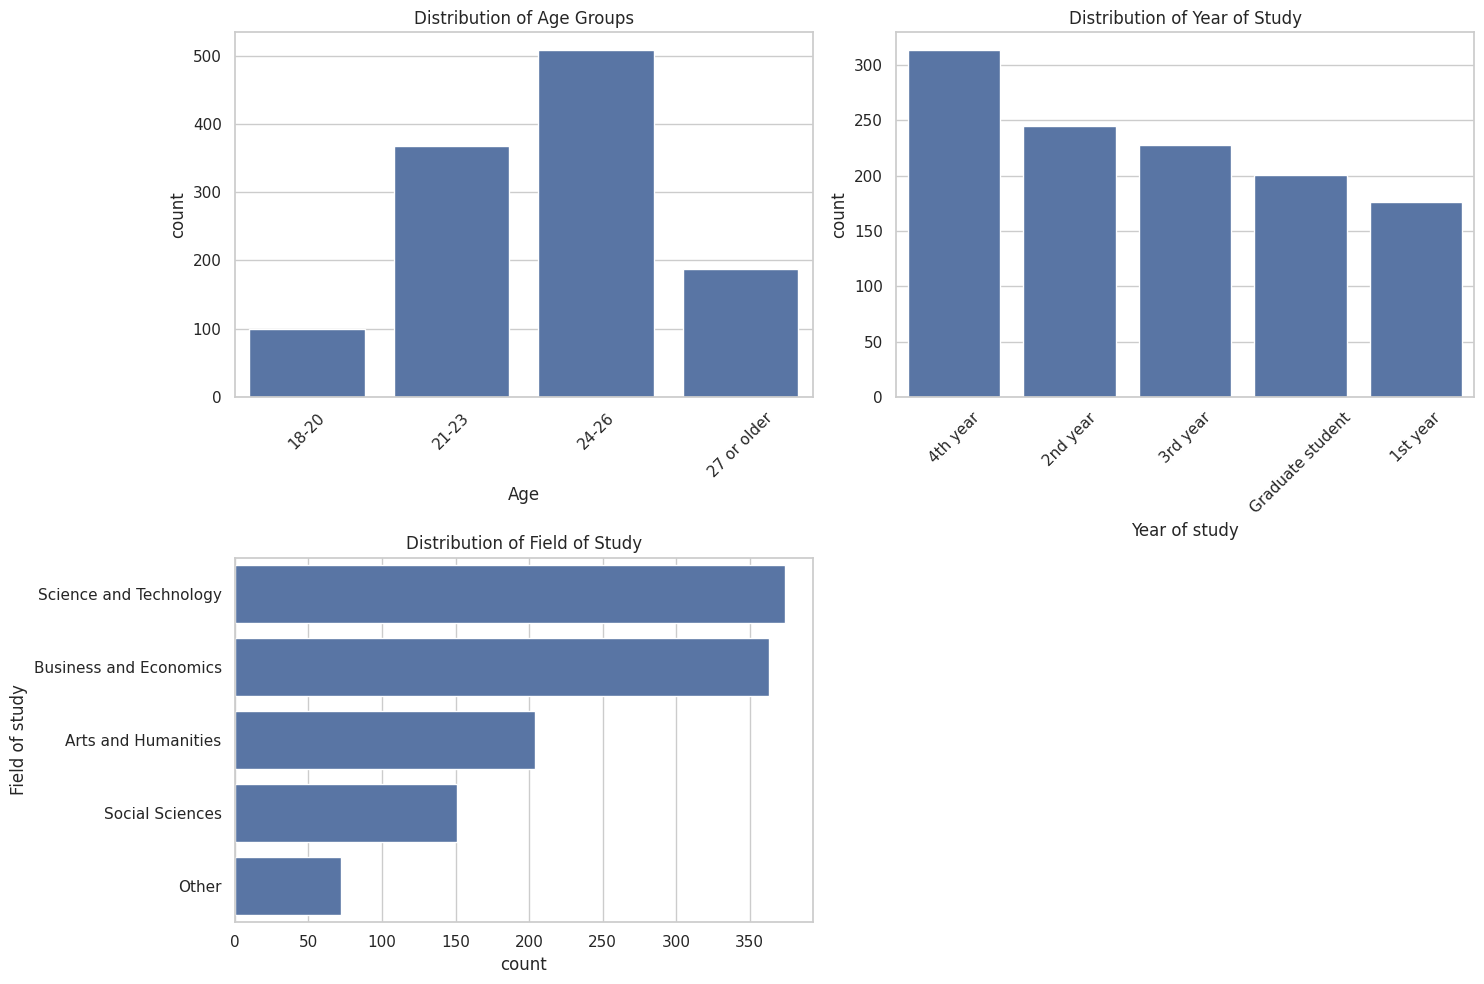

In [2]:
plt.figure(figsize=(15, 10))

# Age Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Age', order=sorted(df['Age'].unique()))
plt.title('Distribution of Age Groups')
plt.xticks(rotation=45)

# Year of Study
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Year of study', order=df['Year of study'].value_counts().index)
plt.title('Distribution of Year of Study')
plt.xticks(rotation=45)

# Field of Study
plt.subplot(2, 2, 3)
sns.countplot(data=df, y='Field of study', order=df['Field of study'].value_counts().index)
plt.title('Distribution of Field of Study')

plt.tight_layout()
plt.show()

## **Substance Use Patterns**
Here we analyze the frequency and primary reasons for smoking and alcohol consumption among students.

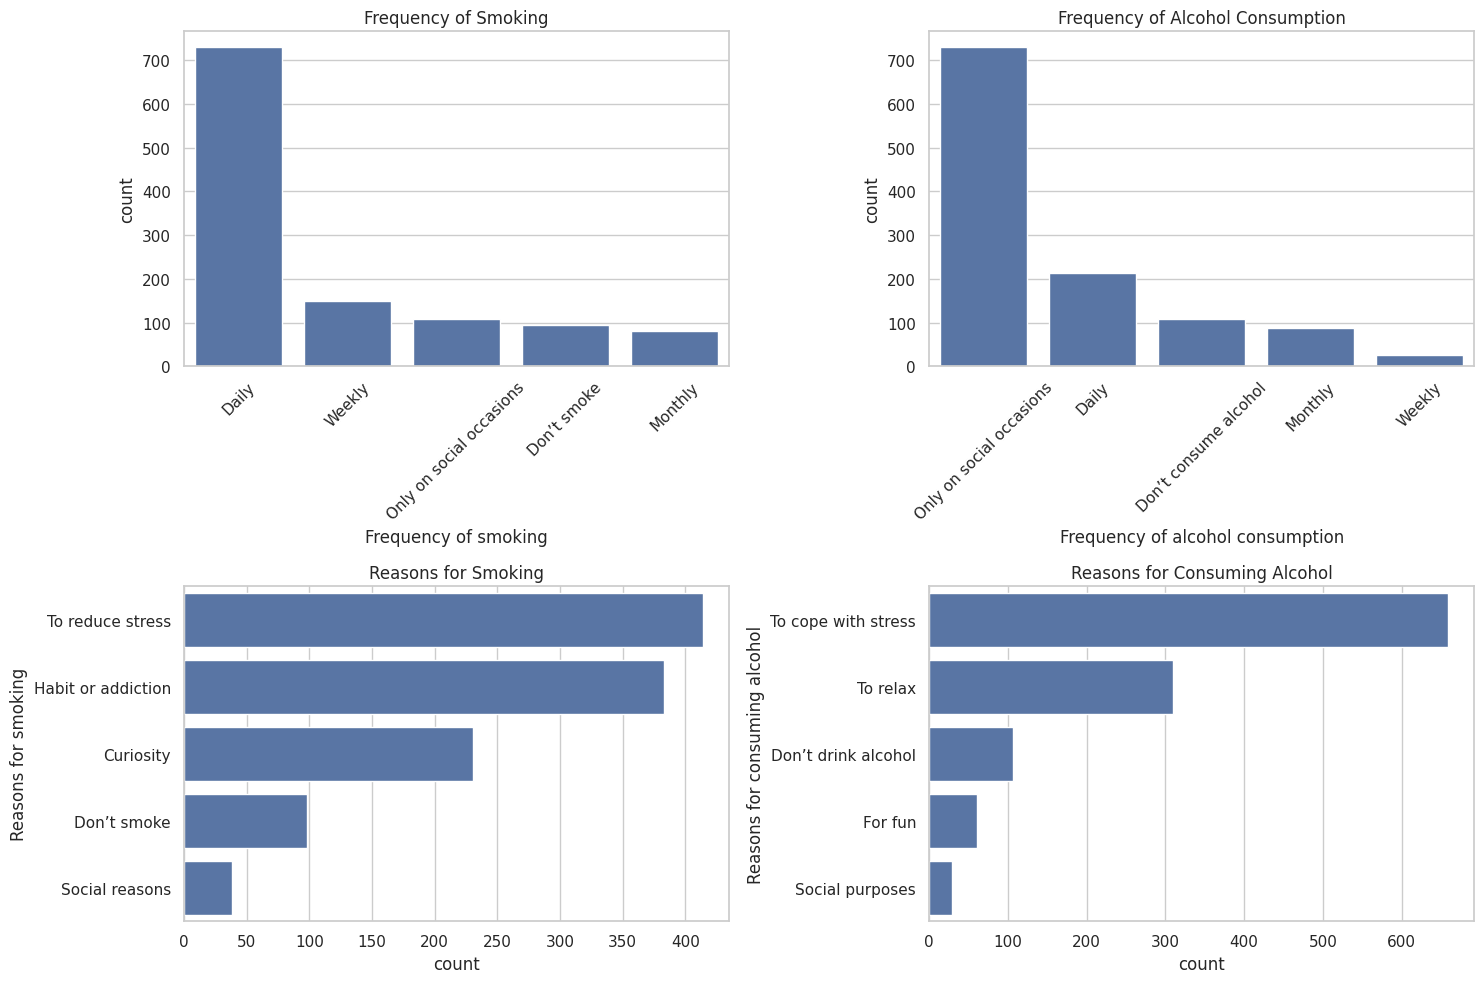

In [3]:
plt.figure(figsize=(15, 10))

# Smoking Frequency
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Frequency of smoking', order=df['Frequency of smoking'].value_counts().index)
plt.title('Frequency of Smoking')
plt.xticks(rotation=45)

# Alcohol Frequency
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Frequency of alcohol consumption', order=df['Frequency of alcohol consumption'].value_counts().index)
plt.title('Frequency of Alcohol Consumption')
plt.xticks(rotation=45)

# Reasons for Smoking
plt.subplot(2, 2, 3)
sns.countplot(data=df, y='Reasons for smoking', order=df['Reasons for smoking'].value_counts().index)
plt.title('Reasons for Smoking')

# Reasons for Alcohol
plt.subplot(2, 2, 4)
sns.countplot(data=df, y='Reasons for consuming alcohol', order=df['Reasons for consuming alcohol'].value_counts().index)
plt.title('Reasons for Consuming Alcohol')

plt.tight_layout()
plt.show()

## **Psychological Wellness and Help-Seeking**
This block focuses on the mental health status of the students and whether they are open to seeking help.

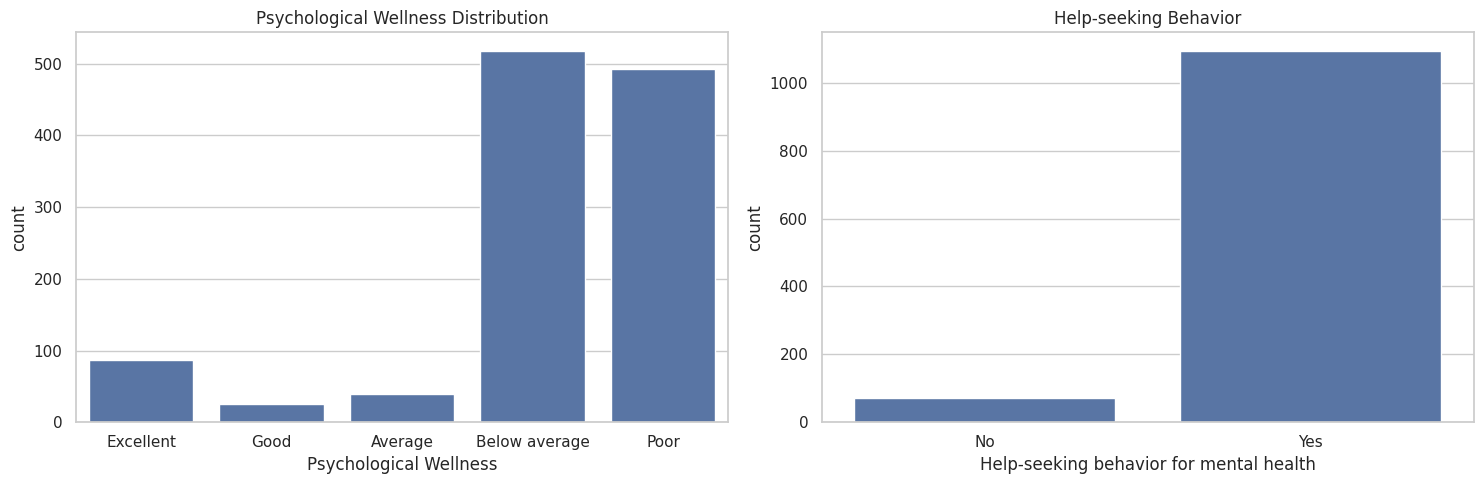

In [4]:
plt.figure(figsize=(15, 5))

# Wellness Distribution
plt.subplot(1, 2, 1)
wellness_order = ['Excellent', 'Good', 'Average', 'Below average', 'Poor']
sns.countplot(data=df, x='Psychological Wellness',
              order=[w for w in wellness_order if w in df['Psychological Wellness'].unique()])
plt.title('Psychological Wellness Distribution')

# Help-seeking Behavior
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Help-seeking behavior for mental health')
plt.title('Help-seeking Behavior')

plt.tight_layout()
plt.show()

## **Correlation: Substance Use vs. Mental Health**
We use heatmaps to see how smoking and alcohol frequency relate to psychological wellness levels.

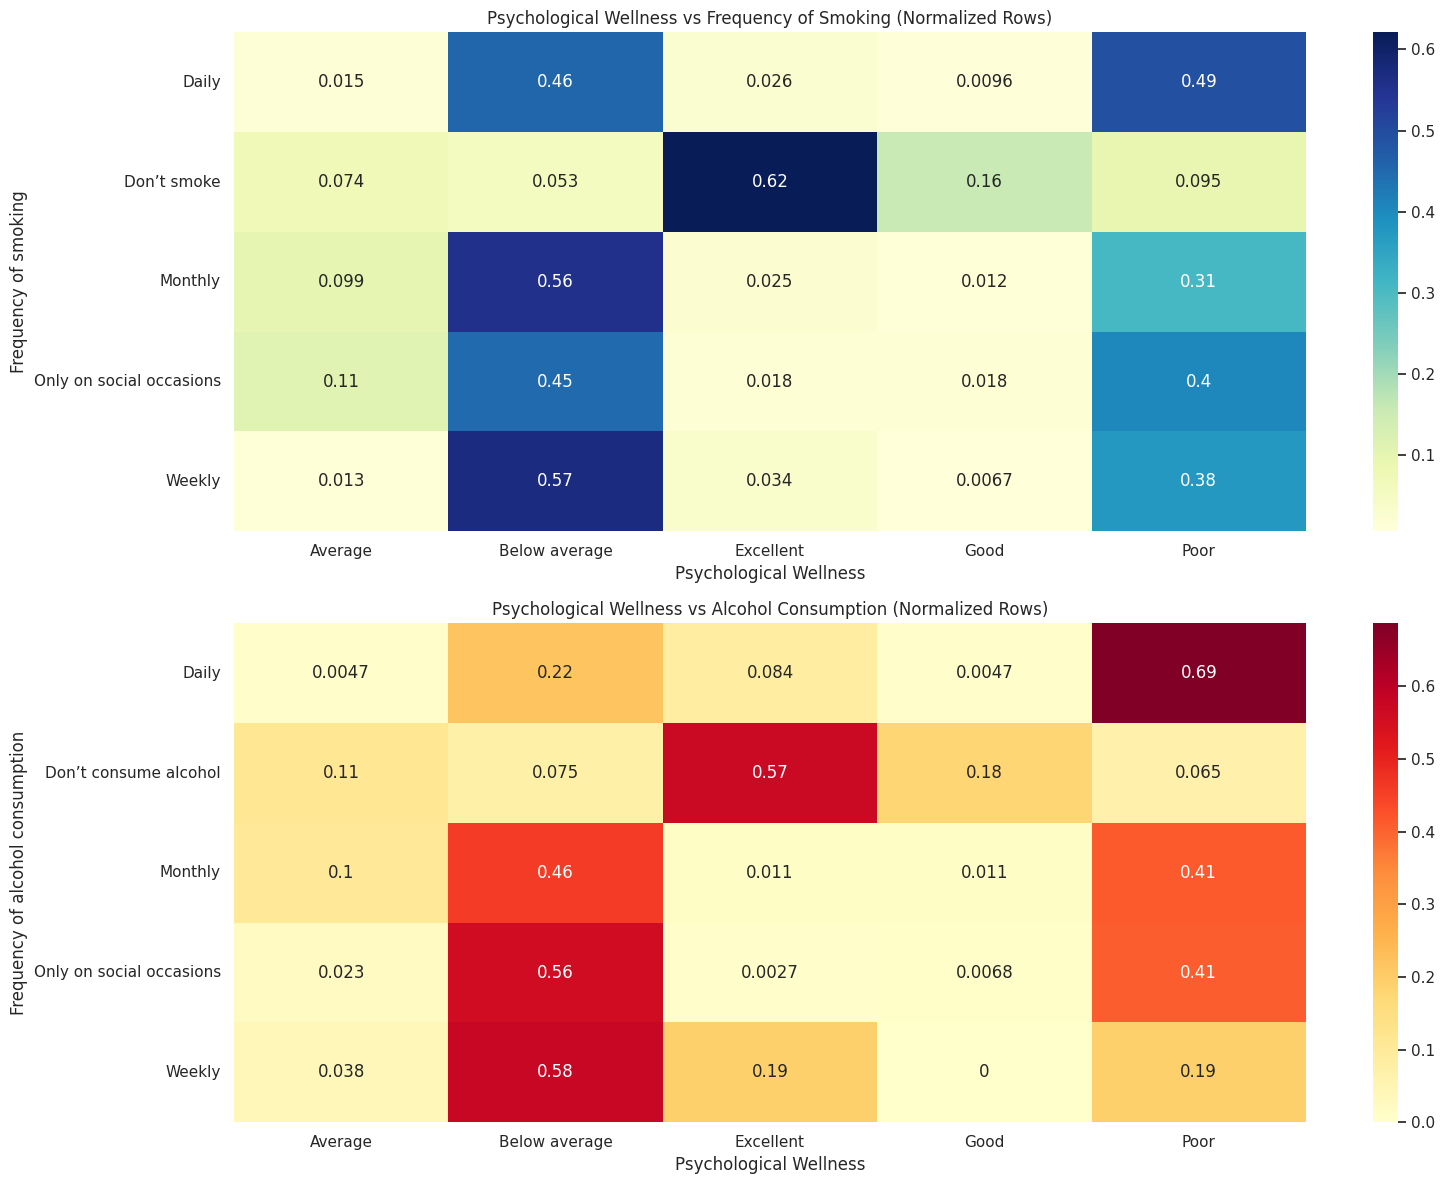

In [5]:
plt.figure(figsize=(16, 12))

# Smoking vs Wellness Heatmap (Normalized)
plt.subplot(2, 1, 1)
ct_smoke = pd.crosstab(df['Frequency of smoking'], df['Psychological Wellness'], normalize='index')
sns.heatmap(ct_smoke, annot=True, cmap='YlGnBu')
plt.title('Psychological Wellness vs Frequency of Smoking (Normalized Rows)')

# Alcohol vs Wellness Heatmap (Normalized)
plt.subplot(2, 1, 2)
ct_alcohol = pd.crosstab(df['Frequency of alcohol consumption'], df['Psychological Wellness'], normalize='index')
sns.heatmap(ct_alcohol, annot=True, cmap='YlOrRd')
plt.title('Psychological Wellness vs Alcohol Consumption (Normalized Rows)')

plt.tight_layout()
plt.show()

## **Correlational HeatMap**

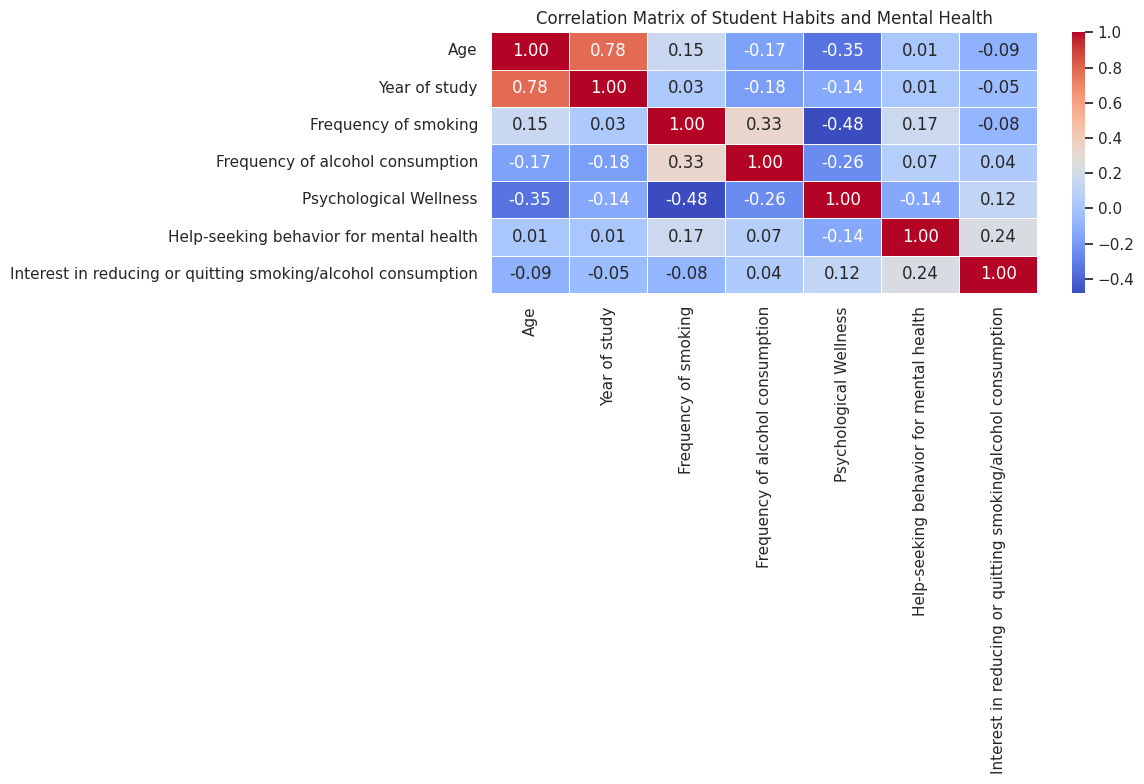

                                                         Age  Year of study  \
Age                                                 1.000000       0.781121   
Year of study                                       0.781121       1.000000   
Frequency of smoking                                0.151703       0.030482   
Frequency of alcohol consumption                   -0.173642      -0.182319   
Psychological Wellness                             -0.346220      -0.137624   
Help-seeking behavior for mental health             0.013991       0.005865   
Interest in reducing or quitting smoking/alcoho... -0.094020      -0.047040   

                                                    Frequency of smoking  \
Age                                                             0.151703   
Year of study                                                   0.030482   
Frequency of smoking                                            1.000000   
Frequency of alcohol consumption                               

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define ordinal mappings for categorical columns
mappings = {
    'Age': {'18-20': 0, '21-23': 1, '24-26': 2, '27 or older': 3},
    'Year of study': {'1st year': 1, '2nd year': 2, '3rd year': 3, '4th year': 4, 'Graduate student': 5},
    'Frequency of smoking': {'Don’t smoke': 0, 'Only on social occasions': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4},
    'Frequency of alcohol consumption': {'Don’t consume alcohol': 0, 'Only on social occasions': 1, 'Monthly': 2, 'Weekly': 3, 'Daily': 4},
    'Psychological Wellness': {'Poor': 0, 'Below average': 1, 'Average': 2, 'Good': 3, 'Excellent': 4},
    'Help-seeking behavior for mental health': {'No': 0, 'Yes': 1},
    'Interest in reducing or quitting smoking/alcohol consumption': {'No': 0, 'Yes': 1}
}

# 2. Create a copy and map values to numeric
df_numeric = df.copy()
for col, mapping in mappings.items():
    df_numeric[col] = df_numeric[col].map(mapping)

# 3. Calculate Correlation Matrix
corr_matrix = df_numeric[list(mappings.keys())].corr()

# 4. Visualize the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Student Habits and Mental Health')
plt.tight_layout()
plt.show()

# Display the raw correlation table
print(corr_matrix)

## **Target Variable Distribution**

/tmp/ipykernel_2629/2730007391.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Psychological Wellness', order=wellness_order, palette='viridis')


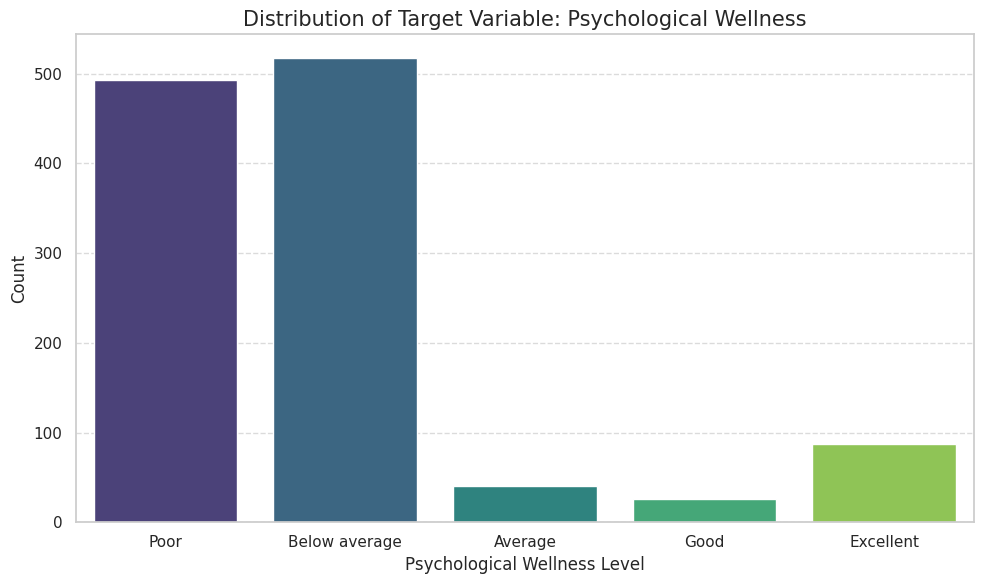

Psychological Wellness
Poor             493
Below average    518
Average           40
Good              26
Excellent         87
Name: count, dtype: int64


In [7]:
# Define the logical order for the wellness categories (from lowest to highest)
wellness_order = ['Poor', 'Below average', 'Average', 'Good', 'Excellent']

# Plot the distribution of the target variable 'Psychological Wellness'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Psychological Wellness', order=wellness_order, palette='viridis')

plt.title('Distribution of Target Variable: Psychological Wellness', fontsize=15)
plt.xlabel('Psychological Wellness Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display value counts for numerical reference
print(df['Psychological Wellness'].value_counts().reindex(wellness_order))

# **3. Feature Engineering & Preprocessing**

## **Grouping Features**

/tmp/ipykernel_2629/781884399.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


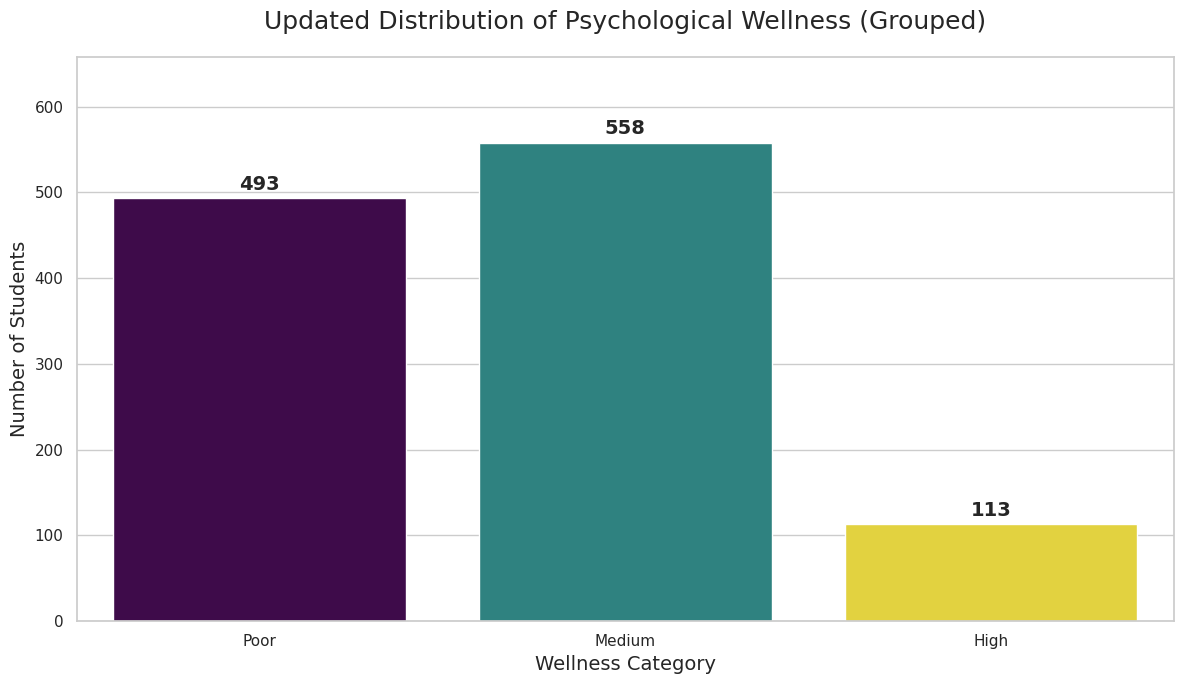

New Category Counts:
Wellness_Grouped
Medium    558
Poor      493
High      113
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the Mapping based on your counts
# Poor: 493 | Medium (Below avg + Average): 558 | High (Good + Excellent): 113
wellness_map = {
    'Poor': 'Poor',
    'Below average': 'Medium',
    'Average': 'Medium',
    'Good': 'High',
    'Excellent': 'High'
}

# 2. Apply mapping to the dataset
df['Wellness_Grouped'] = df['Psychological Wellness'].map(wellness_map)

# 3. Create the Distribution Graph
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Define the order and colors
category_order = ['Poor', 'Medium', 'High']
palette = ["#440154", "#21908d", "#fde725"] # High contrast colors

ax = sns.countplot(
    x='Wellness_Grouped',
    data=df,
    order=category_order,
    palette=palette
)

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=14, fontweight='bold')

plt.title('Updated Distribution of Psychological Wellness (Grouped)', fontsize=18, pad=20)
plt.xlabel('Wellness Category', fontsize=14)
plt.ylabel('Number of Students', fontsize=14)
plt.ylim(0, max(df['Wellness_Grouped'].value_counts()) + 100) # Add space for labels
plt.tight_layout()
plt.show()

# 4. Prepare for Re-training
# Re-encode the new grouped target
from sklearn.preprocessing import LabelEncoder
le_grouped = LabelEncoder()
y_grouped = le_grouped.fit_transform(df['Wellness_Grouped'])
new_classes = le_grouped.classes_

print("New Category Counts:")
print(df['Wellness_Grouped'].value_counts())

In [9]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# 1. Feature Engineering
# Drop non-predictive columns and convert categorical strings to dummy variables
df_model = df.drop(columns=['Timestamp'])
X = pd.get_dummies(df_model.drop(columns=['Wellness_Grouped']), drop_first=True)

# 2. Target Encoding
# Map 'Poor', 'Good', etc., to 0, 1, 2...
le = LabelEncoder()
y = le.fit_transform(df_model['Wellness_Grouped'])
classes = le.classes_
n_classes = len(classes)

# 3. Train-Test Split & Scaling
# Scaling is vital for Logistic Regression and SVM
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **4. Model Training**

In [10]:
# Define the dictionary of models
models = {
    "Logistic Regression": LogisticRegression(multi_class='multinomial', max_iter=1000),
    "SVM": SVC(probability=True, kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # --- Training Phase ---
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    # --- Testing Phase ---
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    test_time = time.time() - start_test

    # Get probabilities for ROC
    y_proba = model.predict_proba(X_test_scaled)

    # Store metrics in a dictionary
    results[name] = {
        "metrics": {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted'),
            "Recall": recall_score(y_test, y_pred, average='weighted'),
            "F1 Score": f1_score(y_test, y_pred, average='weighted'),
            "Train Time (s)": round(train_time, 4),
            "Test Time (s)": round(test_time, 4)
        },
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "y_proba": y_proba,
        "y_pred": y_pred
    }

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## **Model Evaluations**

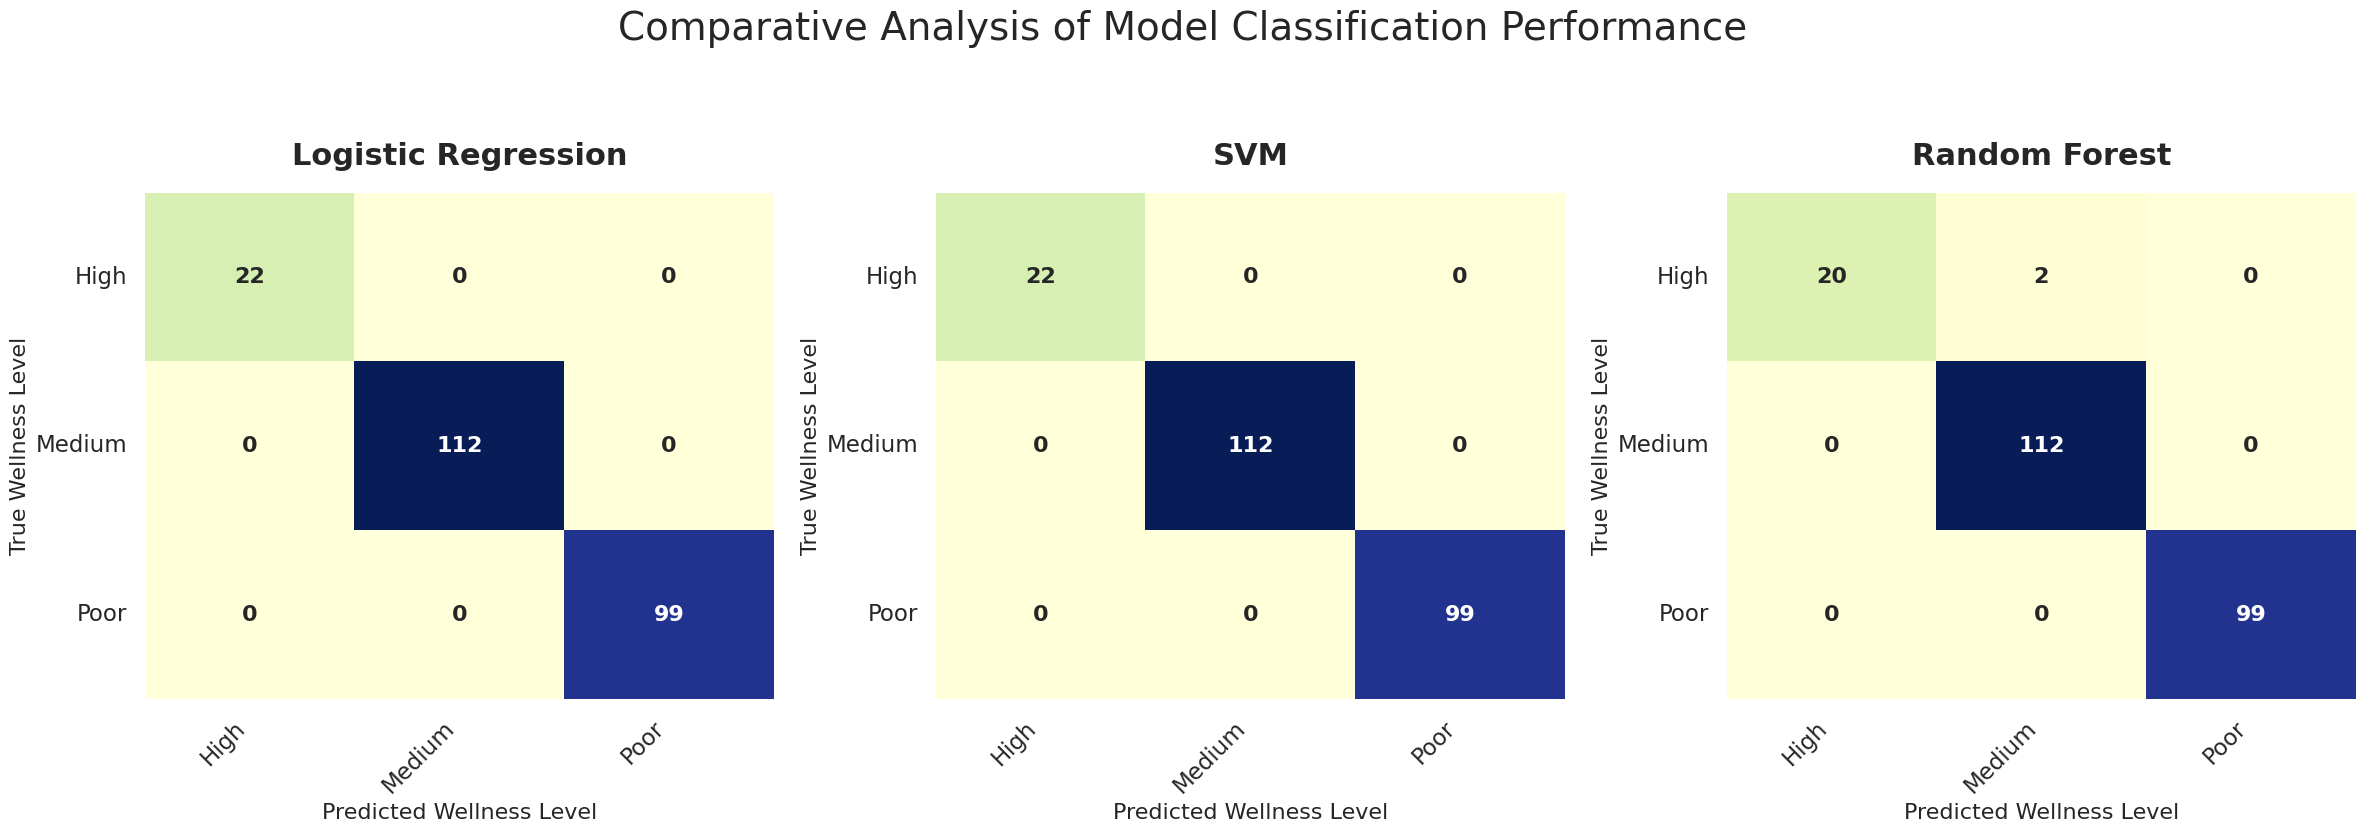

In [11]:
# --- Block 3: Large-Scale Confusion Matrix Visualization ---

# Set a larger font context for better readability
sns.set_context("talk")
sns.set_style("white")

# Create a large figure (Width=24, Height=8)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for i, (name, data) in enumerate(results.items()):
    # Create the heatmap
    sns.heatmap(
        data['conf_matrix'],
        annot=True,
        fmt='d',
        ax=axes[i],
        cmap='YlGnBu', # Changed to Yellow-Green-Blue for high contrast
        cbar=False,    # Remove colorbar to maximize matrix space
        xticklabels=classes,
        yticklabels=classes,
        annot_kws={"size": 16, "weight": "bold"} # Make numbers bigger and bold
    )

    # Customizing titles and labels
    axes[i].set_title(f"{name}", fontsize=22, pad=20, fontweight='bold')
    axes[i].set_ylabel('True Wellness Level', fontsize=16)
    axes[i].set_xlabel('Predicted Wellness Level', fontsize=16)

    # Rotate labels to prevent overlapping
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)

plt.suptitle("Comparative Analysis of Model Classification Performance", fontsize=28, y=1.05)
plt.tight_layout()
plt.show()

# Reset context to default for subsequent plots
sns.set_context("notebook")

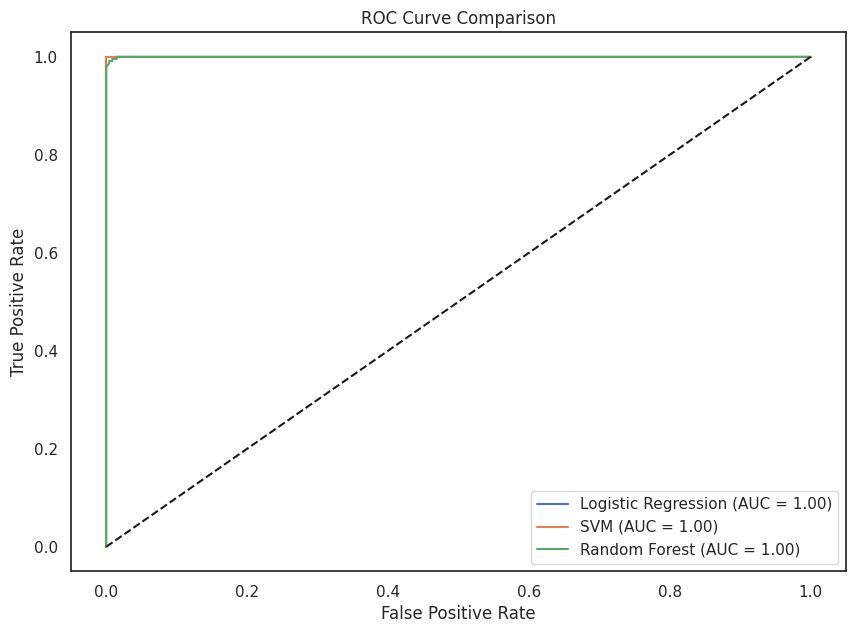

                     Accuracy  Precision    Recall  F1 Score  Train Time (s)  \
Logistic Regression  1.000000   1.000000  1.000000   1.00000          0.0266   
SVM                  1.000000   1.000000  1.000000   1.00000          0.1251   
Random Forest        0.991416   0.991567  0.991416   0.99125          0.1745   

                     Test Time (s)  
Logistic Regression         0.0005  
SVM                         0.0017  
Random Forest               0.0091  


In [12]:
# 1. ROC Curve Plotting
plt.figure(figsize=(10, 7))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

for name, data in results.items():
    # Compute aggregate ROC for multiclass
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), data['y_proba'].ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 2. Performance Summary Table
summary_df = pd.DataFrame({name: data['metrics'] for name, data in results.items()}).T
print(summary_df)

## **Hyperparameter Optimization with Grid Search**

In [13]:
from sklearn.model_selection import GridSearchCV

# 1. Define Parameter Grids for each model
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'solver': ['lbfgs', 'saga'],
        'penalty': ['l2']
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['linear', 'rbf']
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
}

optimized_results = {}

for name, model in models.items():
    print(f"Optimizing {name}...")

    # Setup Grid Search (using 3-fold cross-validation for speed)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1
    )

    # --- Training Phase (includes search time) ---
    start_train = time.time()
    grid_search.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    # Get the best estimator
    best_model = grid_search.best_estimator_

    # --- Testing Phase ---
    start_test = time.time()
    y_pred = best_model.predict(X_test_scaled)
    test_time = time.time() - start_test

    y_proba = best_model.predict_proba(X_test_scaled)

    # Store optimized metrics
    optimized_results[name] = {
        "Best Params": grid_search.best_params_,
        "metrics": {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
            "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
            "Train Time (s)": round(train_time, 4),
            "Test Time (s)": round(test_time, 4)
        },
        "conf_matrix": confusion_matrix(y_test, y_pred),
        "y_proba": y_proba
    }

# Display optimized summary table
opt_summary_df = pd.DataFrame({name: data['metrics'] for name, data in optimized_results.items()}).T
print("\n--- Optimized Model Results ---")
print(opt_summary_df)

# Print best parameters found
for name, data in optimized_results.items():
    print(f"\nBest Parameters for {name}: {data['Best Params']}")

Optimizing Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Optimizing SVM...
Optimizing Random Forest...

--- Optimized Model Results ---
                     Accuracy  Precision    Recall  F1 Score  Train Time (s)  \
Logistic Regression  1.000000   1.000000  1.000000  1.000000          4.9963   
SVM                  1.000000   1.000000  1.000000  1.000000          4.3180   
Random Forest        0.995708   0.995746  0.995708  0.995668         10.0700   

                     Test Time (s)  
Logistic Regression         0.0005  
SVM                         0.0017  
Random Forest               0.0259  

Best Parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Parameters for SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## **Implementing Balancing Strategies**

In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Define the base models
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True, kernel='linear'),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# 2. Define balancing strategies
# Note: SVM and Logistic Regression support 'class_weight', but SMOTE is a separate step
strategies = ["Original", "SMOTE", "Undersampling", "Class-Weighted"]

final_bal_results = []

for model_name, model in base_models.items():
    for strategy in strategies:

        # Configure the specific pipeline or model settings
        if strategy == "Original":
            clf = model
        elif strategy == "SMOTE":
            clf = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', model)])
        elif strategy == "Undersampling":
            clf = ImbPipeline([('rus', RandomUnderSampler(random_state=42)), ('clf', model)])
        elif strategy == "Class-Weighted":
            # Update parameters for cost-sensitive learning
            if model_name == "Random Forest":
                clf = RandomForestClassifier(class_weight='balanced', random_state=42)
            elif model_name == "Logistic Regression":
                clf = LogisticRegression(class_weight='balanced', max_iter=1000)
            elif model_name == "SVM":
                clf = SVC(class_weight='balanced', probability=True, kernel='linear')

        # --- Training and Timing ---
        start_train = time.time()
        clf.fit(X_train_scaled, y_train)
        train_time = time.time() - start_train

        # --- Testing and Timing ---
        start_test = time.time()
        y_pred = clf.predict(X_test_scaled)
        test_time = time.time() - start_test

        # --- Metrics Calculation ---
        final_bal_results.append({
            "Model": model_name,
            "Strategy": strategy,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
            "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
            "Train Time (s)": round(train_time, 4),
            "Test Time (s)": round(test_time, 4)
        })

# 3. Create a clean Summary Table
comparison_df = pd.DataFrame(final_bal_results)
print("\n--- Full Comparison: Models vs. Balancing Strategies ---")
print(comparison_df.sort_values(by="F1 Score", ascending=False).to_string(index=False))


--- Full Comparison: Models vs. Balancing Strategies ---
              Model       Strategy  Accuracy  Precision   Recall  F1 Score  Train Time (s)  Test Time (s)
Logistic Regression       Original  1.000000   1.000000 1.000000  1.000000          0.0573         0.0004
Logistic Regression          SMOTE  1.000000   1.000000 1.000000  1.000000          0.0762         0.0012
Logistic Regression  Undersampling  1.000000   1.000000 1.000000  1.000000          0.0220         0.0009
Logistic Regression Class-Weighted  1.000000   1.000000 1.000000  1.000000          0.0364         0.0005
                SVM       Original  1.000000   1.000000 1.000000  1.000000          0.1225         0.0038
                SVM          SMOTE  1.000000   1.000000 1.000000  1.000000          0.2133         0.0020
                SVM  Undersampling  1.000000   1.000000 1.000000  1.000000          0.0132         0.0014
                SVM Class-Weighted  1.000000   1.000000 1.000000  1.000000          0.0771    


--- Best Performance Summary ---
                 Model  Strategy  F1 Score  Train Time (s)
0  Logistic Regression  Original  1.000000          0.0573
9        Random Forest     SMOTE  0.995668          0.1926
4                  SVM  Original  1.000000          0.1225


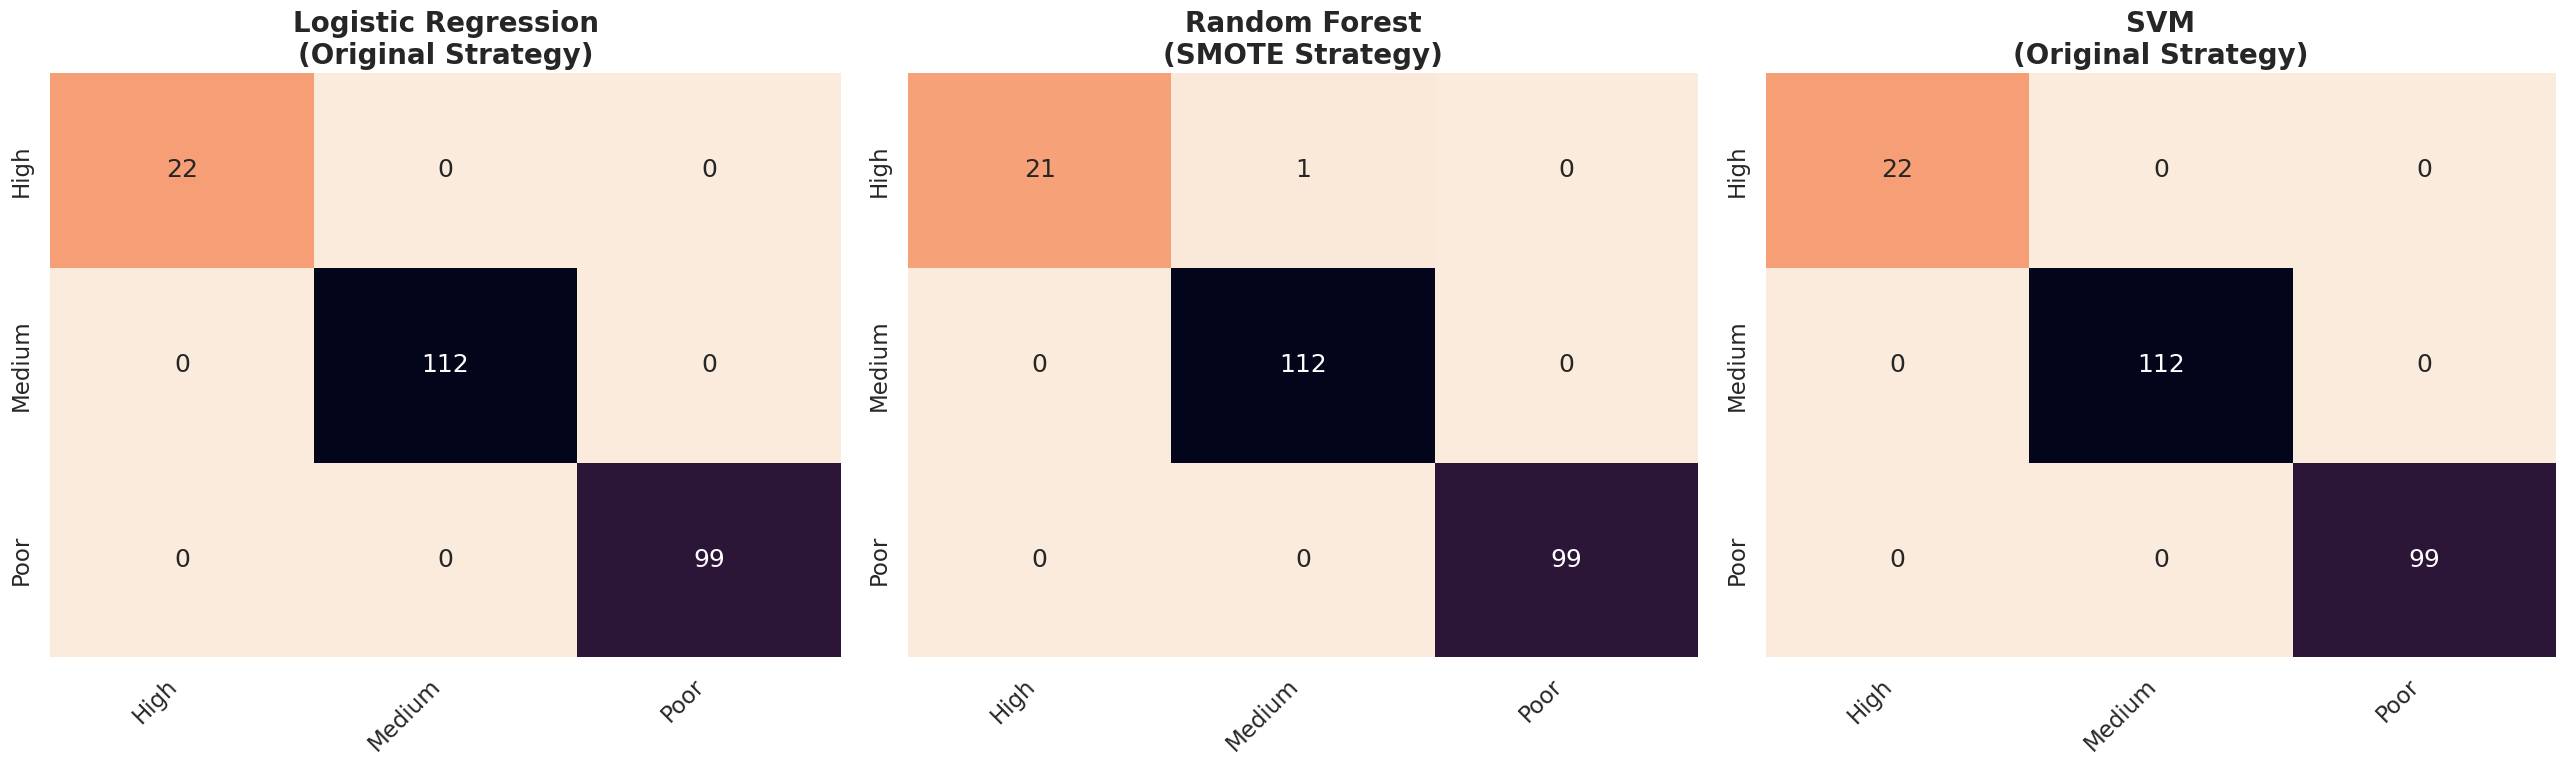

In [15]:
# Select the best version of each model based on F1 Score
best_indices = comparison_df.groupby('Model')['F1 Score'].idxmax()
best_configs = comparison_df.loc[best_indices]

print("\n--- Best Performance Summary ---")
print(best_configs[['Model', 'Strategy', 'F1 Score', 'Train Time (s)']])

# Visualization Setup
sns.set_context("talk")
fig, axes = plt.subplots(1, 3, figsize=(26, 8))

for i, (idx, row) in enumerate(best_configs.iterrows()):
    m_name = row['Model']
    s_name = row['Strategy']

    # Re-run the best model to get the confusion matrix for plotting
    # (In a real scenario, you'd store the matrices in the loop above)
    if s_name == "Original": clf = base_models[m_name]
    elif s_name == "SMOTE": clf = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', base_models[m_name])])
    elif s_name == "Undersampling": clf = ImbPipeline([('rus', RandomUnderSampler(random_state=42)), ('clf', base_models[m_name])])
    else: # Class-Weighted
        if m_name == "Random Forest": clf = RandomForestClassifier(class_weight='balanced', random_state=42)
        elif m_name == "Logistic Regression": clf = LogisticRegression(class_weight='balanced', max_iter=1000)
        else: clf = SVC(class_weight='balanced', probability=True, kernel='linear')

    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='rocket_r',
                xticklabels=classes, yticklabels=classes, cbar=False)

    axes[i].set_title(f"{m_name}\n({s_name} Strategy)", fontweight='bold', fontsize=20)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# **5. Training & Evaluating MLP Model**

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, KFold
from scipy import stats

# 1. Initialize the MLP (Neural Network)
# Using 2 hidden layers with 64 and 32 neurons respectively
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# 2. Define the baseline model to compare against (e.g., Random Forest)
baseline = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Perform 10-Fold Cross-Validation for both
# We use F1-Weighted because of your class imbalance
kf = KFold(n_splits=10, shuffle=True, random_state=42)

print("Starting Cross-Validation for Statistical Test...")
mlp_scores = cross_val_score(mlp, X_train_scaled, y_train, cv=kf, scoring='f1_weighted')
baseline_scores = cross_val_score(baseline, X_train_scaled, y_train, cv=kf, scoring='f1_weighted')

# 4. Calculate All Evaluation Metrics for MLP on Test Set
start_train = time.time()
mlp.fit(X_train_scaled, y_train)
train_time = time.time() - start_train

start_test = time.time()
y_pred_mlp = mlp.predict(X_test_scaled)
test_time = time.time() - start_test

mlp_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp, average='weighted', zero_division=0),
    "Recall": recall_score(y_test, y_pred_mlp, average='weighted', zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0),
    "Train Time (s)": round(train_time, 4),
    "Test Time (s)": round(test_time, 4)
}

# 5. Statistical Significance Test (Paired T-Test)
t_stat, p_value = stats.ttest_rel(mlp_scores, baseline_scores)

# --- RESULTS SUMMARY ---
print("\n" + "="*30)
print("MLP Performance Metrics:")
for k, v in mlp_metrics.items():
    print(f"{k}: {v}")

print("\n" + "="*30)
print(f"Paired T-Test Results (MLP vs Baseline):")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("RESULT: The improvement is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print("RESULT: The improvement is NOT statistically significant (p >= 0.05).")

Starting Cross-Validation for Statistical Test...

MLP Performance Metrics:
Accuracy: 0.9914163090128756
Precision: 0.9914163090128756
Recall: 0.9914163090128756
F1 Score: 0.9914163090128756
Train Time (s): 0.5749
Test Time (s): 0.001

Paired T-Test Results (MLP vs Baseline):
T-statistic: -1.6064
P-value: 0.1426
RESULT: The improvement is NOT statistically significant (p >= 0.05).


# **6. K-Fold Cross Validation**

Starting 10-Fold Cross-Validation for all models...

--- Final Cross-Validation Comparison ---
               Model  Mean Accuracy  Std Dev (Acc)  Mean F1-Score  Std Dev (F1)
 Logistic Regression       1.000000       0.000000       1.000000      0.000000
                 SVM       1.000000       0.000000       1.000000      0.000000
       Random Forest       0.995699       0.007133       0.995695      0.007136
MLP (Neural Network)       0.984969       0.013760       0.984983      0.013702


/tmp/ipykernel_2629/241583198.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


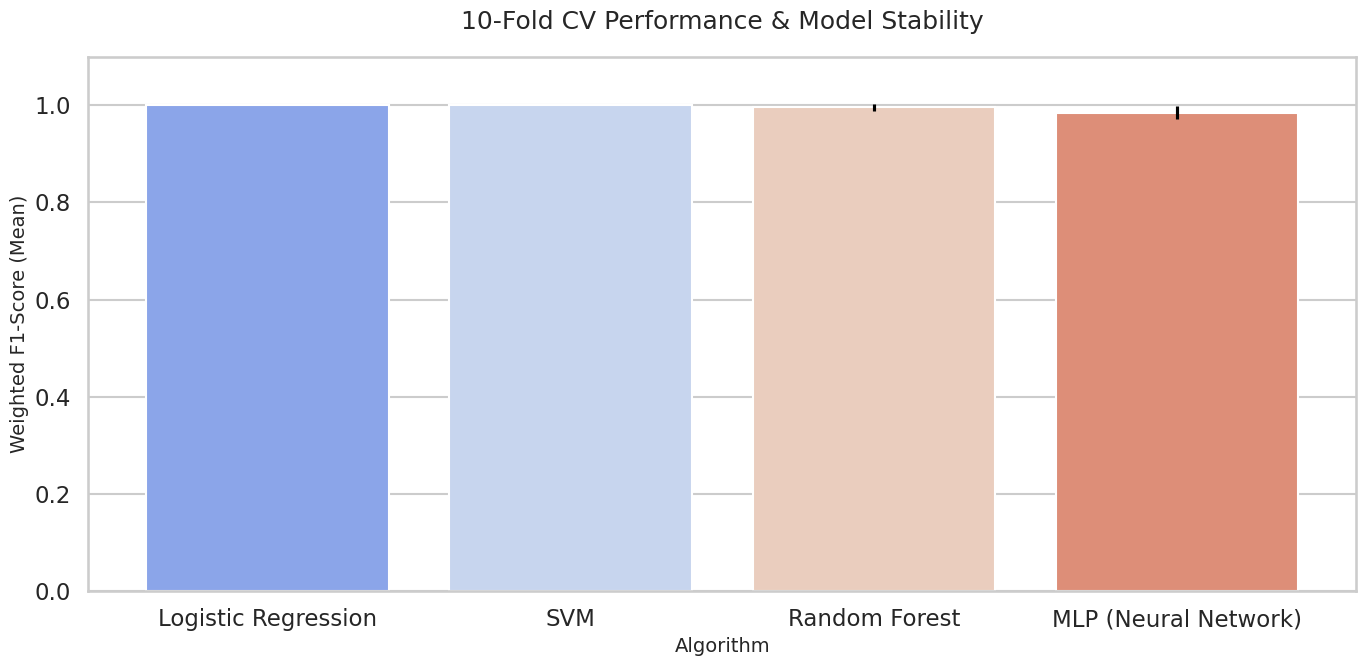

In [17]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd
import numpy as np

# 1. Update the 'models' dictionary with your BEST parameters from GridSearch
# This ensures we are testing the most powerful versions of your models
optimized_models = {
    "Logistic Regression": LogisticRegression(C=1, penalty='l2', solver='lbfgs', max_iter=1000),
    "SVM": SVC(C=0.1, kernel='linear', gamma='scale', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2, random_state=42),
    "MLP (Neural Network)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 2. Setup the CV Strategy
# 10 folds provide a more robust statistical estimate than 5
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results_all = []

print("Starting 10-Fold Cross-Validation for all models...")

# 3. Execution Loop
for name, model in optimized_models.items():
    # We track Accuracy and F1-Weighted to account for class distribution
    scoring_metrics = ['accuracy', 'f1_weighted']

    cv_output = cross_validate(
        model,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring=scoring_metrics,
        n_jobs=-1 # Uses all CPU cores for speed
    )

    # Calculate Mean and Standard Deviation (Stability)
    cv_results_all.append({
        "Model": name,
        "Mean Accuracy": cv_output['test_accuracy'].mean(),
        "Std Dev (Acc)": cv_output['test_accuracy'].std(),
        "Mean F1-Score": cv_output['test_f1_weighted'].mean(),
        "Std Dev (F1)": cv_output['test_f1_weighted'].std()
    })

# 4. Display the Performance Table
final_cv_df = pd.DataFrame(cv_results_all).sort_values(by="Mean F1-Score", ascending=False)
print("\n--- Final Cross-Validation Comparison ---")
print(final_cv_df.to_string(index=False))

# 5. Visualize with Error Bars (Stability Analysis)
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(
    data=final_cv_df,
    x='Model',
    y='Mean F1-Score',
    palette='coolwarm',
    capsize=.1
)

# Add the error bars manually for better control
plt.errorbar(
    x=np.arange(len(final_cv_df)),
    y=final_cv_df['Mean F1-Score'],
    yerr=final_cv_df['Std Dev (F1)'],
    fmt='none', c='black'
)

plt.title('10-Fold CV Performance & Model Stability', fontsize=18, pad=20)
plt.ylabel('Weighted F1-Score (Mean)', fontsize=14)
plt.xlabel('Algorithm', fontsize=14)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# **7. Model Interpretability**

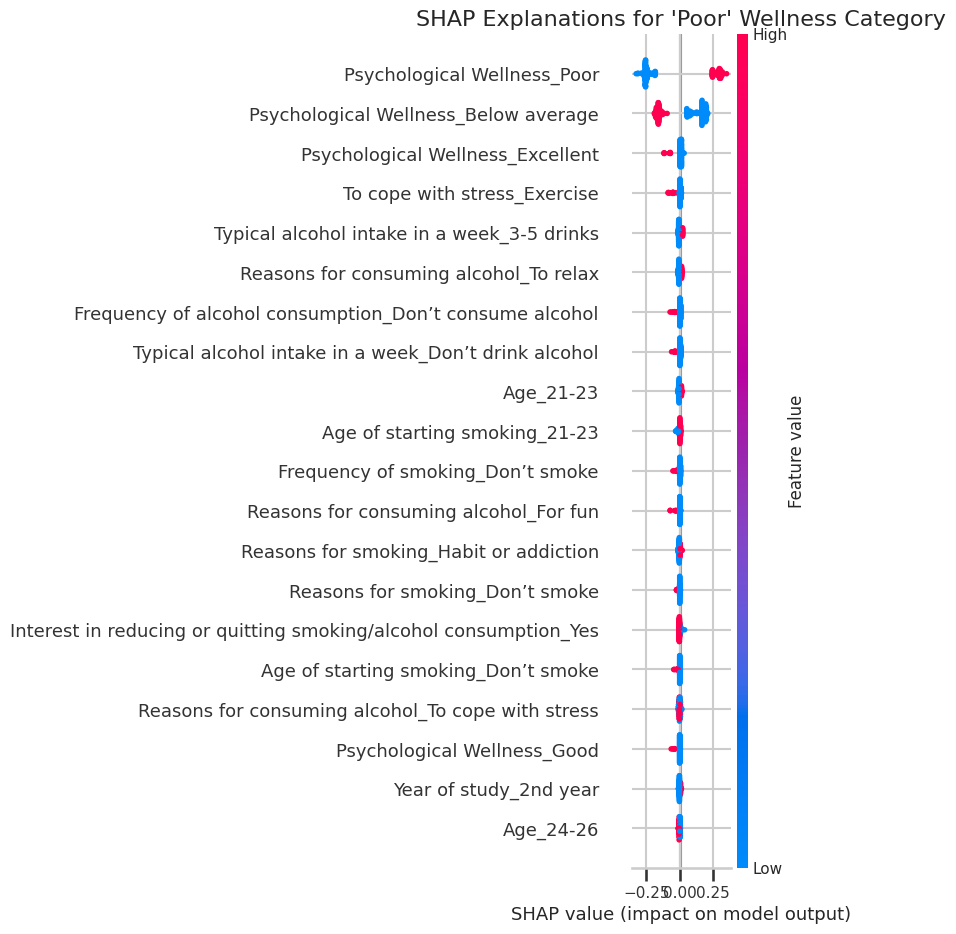

In [18]:
import shap
import numpy as np
import pandas as pd

# 1. Initialize Explainer
rf_model = models["Random Forest"]
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values
# We use X_test_scaled because that's what the model was trained on
shap_values = explainer.shap_values(X_test_scaled)

# 3. CRITICAL FIX: Handle the indexing and shape
# In multiclass Random Forest, shap_values is a list of arrays: [Class0, Class1, Class2]
# We need to find the index for 'Poor'
poor_idx = np.where(classes == 'Poor')[0][0]

# Extract the values for 'Poor'
# Sometimes TreeExplainer returns (samples, features, classes),
# but usually it's a list of (samples, features).
if isinstance(shap_values, list):
    poor_shap_values = shap_values[poor_idx]
else:
    # If it's a 3D array (samples, features, classes)
    poor_shap_values = shap_values[:, :, poor_idx]

# 4. Final Plotting
# We pass X_test (the DataFrame) to provide feature names,
# and poor_shap_values which now matches X_test.shape exactly.
plt.figure(figsize=(12, 8))

# If poor_shap_values still causes a shape error, we slice it to match X_test
shap.summary_plot(
    poor_shap_values,
    X_test,
    feature_names=X_test.columns,
    show=False
)

plt.title(f"SHAP Explanations for 'Poor' Wellness Category", fontsize=16)
plt.show()

/tmp/ipykernel_2629/1512534912.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


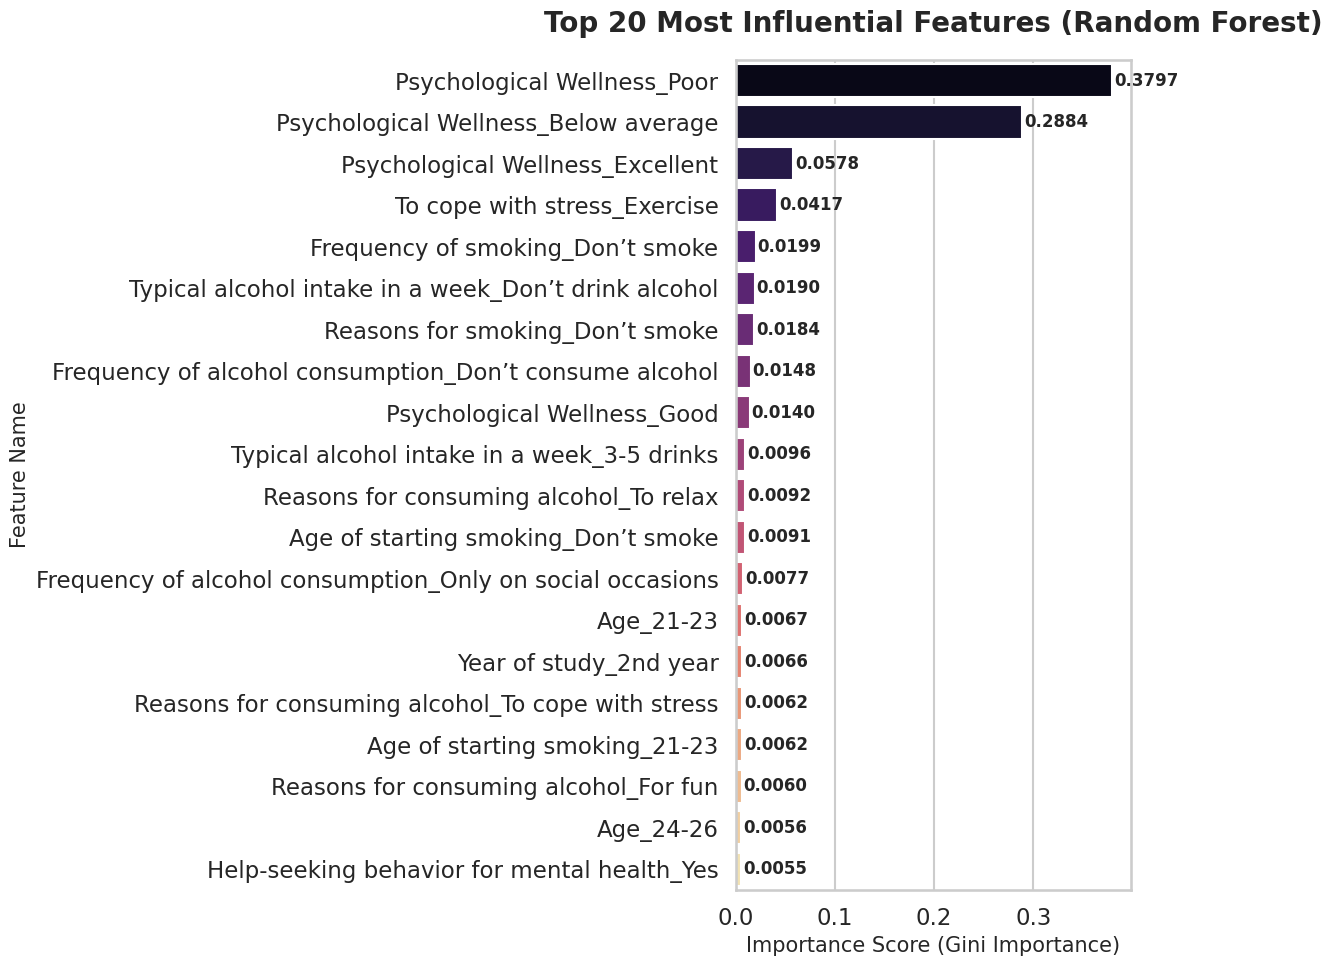

Top 10 Most Important Features:
                                               Feature  Importance
                           Psychological Wellness_Poor    0.379742
                  Psychological Wellness_Below average    0.288351
                      Psychological Wellness_Excellent    0.057821
                          To cope with stress_Exercise    0.041705
                      Frequency of smoking_Don’t smoke    0.019950
  Typical alcohol intake in a week_Don’t drink alcohol    0.018966
                       Reasons for smoking_Don’t smoke    0.018439
Frequency of alcohol consumption_Don’t consume alcohol    0.014844
                           Psychological Wellness_Good    0.013968
           Typical alcohol intake in a week_3-5 drinks    0.009591


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importance from the Random Forest model
# Note: 'models' is the dictionary you created in your training block
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns # These are the column names after get_dummies

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Top 20 Features
plt.figure(figsize=(12, 10))
sns.set_context("talk")

# Use a color palette that highlights the most important features
ax = sns.barplot(
    data=feature_importance_df.head(20),
    x='Importance',
    y='Feature',
    palette='magma'
)

# Add title and labels
plt.title('Top 20 Most Influential Features (Random Forest)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Importance Score (Gini Importance)', fontsize=15)
plt.ylabel('Feature Name', fontsize=15)

# Add value labels to the end of each bar for precision
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.002, p.get_y() + p.get_height() / 2,
            f'{width:.4f}', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Print the top 10 for quick reference
print("Top 10 Most Important Features:")
print(feature_importance_df.head(10).to_string(index=False))